In [2]:
import simpy
import random
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go

# Pengaturan benih acak agar hasil konsisten saat pengujian
random.seed(42)

In [3]:
# Konstanta
JUMLAH_OMPRENG = 180
WAKTU_MULAI_SIMULASI = "07:00:00"

# Alokasi Petugas (Total harus 7)
STAF_LAUK = 3
STAF_ANGKAT = 2
STAF_NASI = 2 

assert (STAF_LAUK + STAF_ANGKAT + STAF_NASI) == 7, "Total staf harus berjumlah 7 orang!"

In [4]:
class PiketITDel:
    def __init__(self, env, n_lauk, n_angkat, n_nasi):
        self.env = env
        self.lauk = simpy.Resource(env, capacity=n_lauk)
        self.angkat = simpy.Resource(env, capacity=n_angkat)
        self.nasi = simpy.Resource(env, capacity=n_nasi)
        
        # Buffer untuk proses angkat (karena angkat bersifat batch/borongan)
        self.buffer_angkat = simpy.Store(env)
        self.data_log = []

    def proses_lauk(self, id_ompreng):
        datang = self.env.now
        
        # 1. Tahap Isi Lauk
        with self.lauk.request() as req:
            yield req
            mulai_layanan = self.env.now
            durasi = random.uniform(30, 60)
            yield self.env.timeout(durasi)
            
            # Selesai isi lauk, masukkan ke buffer untuk diangkat
            info_ompreng = {
                "id": id_ompreng,
                "waktu_datang": datang,
                "mulai_lauk": mulai_layanan,
                "selesai_lauk": self.env.now
            }
            yield self.buffer_angkat.put(info_ompreng)

    def proses_angkat_batch(self):
        """Proses petugas mengambil 4-7 ompreng dari meja lauk ke meja nasi"""
        while True:
            # Petugas menunggu sampai ada minimal 4 ompreng di buffer (atau sisa terakhir)
            batch_size = random.randint(4, 7)
            items = []
            
            # Ambil item dari buffer
            for _ in range(batch_size):
                if len(self.buffer_angkat.items) > 0 or len(self.data_log) < JUMLAH_OMPRENG:
                    item = yield self.buffer_angkat.get()
                    items.append(item)
                    if len(self.buffer_angkat.items) == 0 and len(self.data_log) + len(items) >= JUMLAH_OMPRENG:
                        break
                if len(items) >= batch_size: break

            if not items:
                yield self.env.timeout(1)
                continue

            # 2. Tahap Angkat (Satu petugas membawa satu batch)
            with self.angkat.request() as req:
                yield req
                mulai_angkat = self.env.now
                durasi_angkat = random.uniform(20, 60)
                yield self.env.timeout(durasi_angkat)
                
                selesai_angkat = self.env.now
                for item in items:
                    item['mulai_angkat'] = mulai_angkat
                    item['selesai_angkat'] = selesai_angkat
                    self.env.process(self.proses_nasi(item))

    def proses_nasi(self, item):
        # 3. Tahap Isi Nasi
        with self.nasi.request() as req:
            yield req
            mulai_nasi = self.env.now
            durasi_nasi = random.uniform(30, 60)
            yield self.env.timeout(durasi_nasi)
            
            item['mulai_nasi'] = mulai_nasi
            item['selesai_nasi'] = self.env.now
            self.data_log.append(item)

def jalankan_simulasi(n_lauk, n_angkat, n_nasi):
    env = simpy.Environment()
    sistem = PiketITDel(env, n_lauk, n_angkat, n_nasi)
    
    # Generate ompreng yang masuk ke sistem
    for i in range(JUMLAH_OMPRENG):
        env.process(sistem.proses_lauk(i))
    
    # Jalankan monitor angkat
    env.process(sistem.proses_angkat_batch())
    
    env.run()
    return sistem.data_log

In [5]:
# Eksekusi
raw_data = jalankan_simulasi(STAF_LAUK, STAF_ANGKAT, STAF_NASI)

# Konversi ke DataFrame
df = pd.DataFrame(raw_data)
df['durasi_total'] = df['selesai_nasi'] - df['waktu_datang']
df['waktu_tunggu'] = df['durasi_total'] - ( (df['selesai_lauk']-df['mulai_lauk']) + 
                                           (df['selesai_angkat']-df['mulai_angkat']) + 
                                           (df['selesai_nasi']-df['mulai_nasi']) )

# Konversi Jam
start_dt = datetime.strptime(WAKTU_MULAI_SIMULASI, "%H:%M:%S")
df['jam_selesai'] = df['selesai_nasi'].apply(lambda x: (start_dt + timedelta(seconds=x)).strftime("%H:%M:%S"))

print("Simulasi Selesai!")
df.head()

Simulasi Selesai!


,id,waktu_datang,mulai_lauk,selesai_lauk,mulai_angkat,selesai_angkat,mulai_nasi,selesai_nasi,durasi_total,waktu_tunggu,jam_selesai
0,0,0,0.000000,30.750323,82.844459,106.322012,106.322012,153.159364,153.159364,52.094136,07:02:33
1,2,0,0.000000,36.696322,82.844459,106.322012,106.322012,157.802601,157.802601,46.148137,07:02:37
2,1,0,0.000000,38.250880,82.844459,106.322012,153.159364,209.238374,209.238374,91.430931,07:03:29
3,3,0,30.750323,82.844459,82.844459,106.322012,157.802601,210.566822,210.566822,82.230911,07:03:30
4,4,0,36.696322,86.997307,125.502114,162.282907,209.238374,242.139865,242.139865,122.156596,07:04:02


In [6]:
# Menghitung Metrik Utama
rata_durasi = df['durasi_total'].mean() / 60
waktu_selesai_akhir = df['jam_selesai'].max()
total_waktu_menit = df['selesai_nasi'].max() / 60

print(f"--- LAPORAN HASIL PIKET ---")
print(f"Total Ompreng      : {JUMLAH_OMPRENG}")
print(f"Alokasi Petugas    : Lauk({STAF_LAUK}), Angkat({STAF_ANGKAT}), Nasi({STAF_NASI})")
print(f"Rata-rata Layanan  : {rata_durasi:.2f} Menit")
print(f"Total Waktu Kerja  : {total_waktu_menit:.2f} Menit")
print(f"Piket Selesai Jam  : {waktu_selesai_akhir}")

--- LAPORAN HASIL PIKET ---
Total Ompreng      : 180
Alokasi Petugas    : Lauk(3), Angkat(2), Nasi(2)
Rata-rata Layanan  : 36.67 Menit
Total Waktu Kerja  : 71.25 Menit
Piket Selesai Jam  : 08:11:15


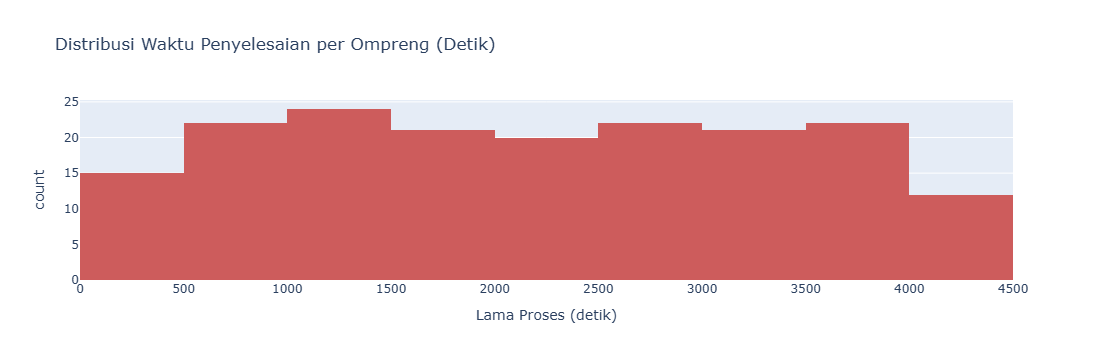

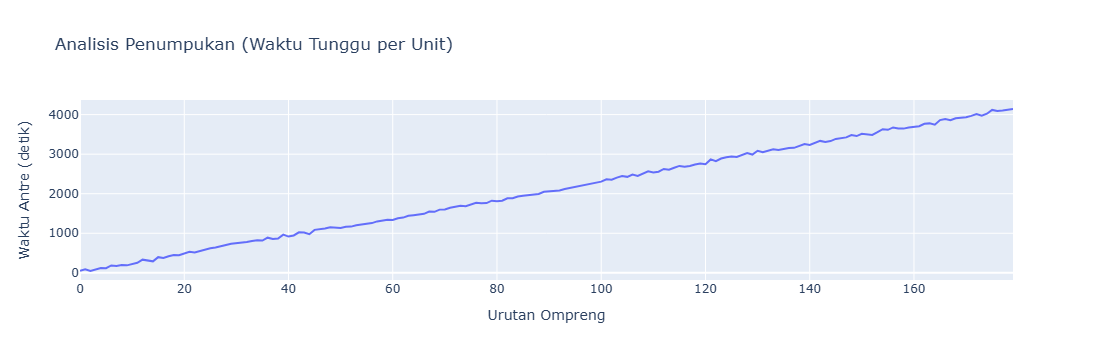

In [7]:
# Visualisasi Distribusi Waktu Selesai
fig = px.histogram(df, x="durasi_total", 
                   title="Distribusi Waktu Penyelesaian per Ompreng (Detik)",
                   labels={'durasi_total': 'Lama Proses (detik)'},
                   color_discrete_sequence=['indianred'])
fig.show()

# Visualisasi Bottleneck (Tren Antrean)
fig2 = px.line(df.sort_values('id'), x="id", y="waktu_tunggu",
              title="Analisis Penumpukan (Waktu Tunggu per Unit)",
              labels={'id': 'Urutan Ompreng', 'waktu_tunggu': 'Waktu Antre (detik)'})
fig2.show()